# **Analysis of fitness_data**


- Tmax = 5000 generations
- Number of replicates = 10000 replicates (two rounds of 5000 replicates)
- Size of array = 40 spacers
- Script: simulate_spacers1.2

## **Data description**

- **Columns**: parameters that identify the simulation followed by values assigned for the analysis of the fitness curves: maxima, minima, ratio between maxima and distance between midpoints.
- **Rows**: different simulations that differ in the input parameters.
---

## **Preprocessing**


In this step we will carry on different preprocessing procedures in order to compare which one yields better clustering results.

1.   Open and visualize the 'data.csv' file.
2.   Look for and handle (if needed) missing values.
3.   Categoric to numeric.
4.   Standarization and normalization.



In [1]:
import pandas as pd  
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

### **Data preparation**



In [2]:
input_file = "/Users/jimenamartinreina/Documents/UNI/MASTER/PRACTICAS_TFM/MODELO/NSP40/ANALYSIS/fitness_data.txt"
output_file = "/Users/jimenamartinreina/Documents/UNI/MASTER/PRACTICAS_TFM/MODELO/NSP40/ANALYSIS/fitness_data.csv"

df = pd.read_csv(input_file, sep="\t", engine="python")
df.to_csv(output_file, index=False)  

print(f"File converted and saved as: {output_file}")

File converted and saved as: /Users/jimenamartinreina/Documents/UNI/MASTER/PRACTICAS_TFM/MODELO/NSP40/ANALYSIS/fitness_data.csv


In [3]:
open("/Users/jimenamartinreina/Documents/UNI/MASTER/PRACTICAS_TFM/MODELO/NSP40/ANALYSIS/fitness_data.csv", "r")

<_io.TextIOWrapper name='/Users/jimenamartinreina/Documents/UNI/MASTER/PRACTICAS_TFM/MODELO/NSP40/ANALYSIS/fitness_data.csv' mode='r' encoding='UTF-8'>

In [4]:
open("/Users/jimenamartinreina/Documents/UNI/MASTER/PRACTICAS_TFM/MODELO/NSP40/ANALYSIS/sorted_fitness_data.csv", "r")

<_io.TextIOWrapper name='/Users/jimenamartinreina/Documents/UNI/MASTER/PRACTICAS_TFM/MODELO/NSP40/ANALYSIS/sorted_fitness_data.csv' mode='r' encoding='UTF-8'>

In [5]:
df = pd.read_csv('/Users/jimenamartinreina/Documents/UNI/MASTER/PRACTICAS_TFM/MODELO/NSP40/ANALYSIS/fitness_data.csv',engine='python')

In [6]:
# First inspection of the data (dimensions, aspect, missing values)
data_info = {
    "shape": df.shape,
    "head": df.head(),
    "missing_values": df.isnull().sum().sum()
}
data_info

{'shape': (450, 9),
 'head':         parameters  max_left_position  max_left_value  max_right_position  \
 0   0.36_5.00_0.10                  0         0.93050                  39   
 1   0.77_5.00_0.80                  0         0.34535                  39   
 2  0.10_10.00_0.40                  4         0.95875                  36   
 3  0.60_10.00_0.50                  2         0.67560                  39   
 4  0.28_20.00_0.30                  9         0.91830                  39   
 
    max_right_value  min_position  min_value  ratio_of_peaks  \
 0          0.51345            22    0.12505          1.8123   
 1          0.20830            17    0.18545          1.6579   
 2          0.89620            14    0.54430          1.0698   
 3          0.34150            20    0.21095          1.9783   
 4          0.69220            26    0.28300          1.3266   
 
    euclidean_distance  
 0             31.2488  
 1             29.7346  
 2             10.5176  
 3             2

In [7]:
#What are the column data types?
print("Columns data types:\n{}".format(df.dtypes))

Columns data types:
parameters             object
max_left_position       int64
max_left_value        float64
max_right_position      int64
max_right_value       float64
min_position            int64
min_value             float64
ratio_of_peaks        float64
euclidean_distance    float64
dtype: object


In [8]:
numeric_cols = df.select_dtypes(include=['number']).columns
print(numeric_cols)
categorical_cols = df.select_dtypes(exclude=['number']).columns
print(categorical_cols)
numeric_df = df.select_dtypes(include=[np.number])
print(numeric_df)

Index(['max_left_position', 'max_left_value', 'max_right_position',
       'max_right_value', 'min_position', 'min_value', 'ratio_of_peaks',
       'euclidean_distance'],
      dtype='object')
Index(['parameters'], dtype='object')
     max_left_position  max_left_value  max_right_position  max_right_value  \
0                    0         0.93050                  39          0.51345   
1                    0         0.34535                  39          0.20830   
2                    4         0.95875                  36          0.89620   
3                    2         0.67560                  39          0.34150   
4                    9         0.91830                  39          0.69220   
..                 ...             ...                 ...              ...   
445                  4         0.91290                  39          0.70175   
446                  7         0.82960                  37          0.77585   
447                  1         0.91950                  36

In [9]:
sorted_df = pd.read_csv('/Users/jimenamartinreina/Documents/UNI/MASTER/PRACTICAS_TFM/MODELO/NSP40/ANALYSIS/sorted_fitness_data.csv',engine='python')

In [10]:
sorted_numeric_df = sorted_df.select_dtypes(include=[np.number])

#### **Quality cheks**

In [11]:
duplicates = df.duplicated()
df[duplicates]

,parameters,max_left_position,max_left_value,max_right_position,max_right_value,min_position,min_value,ratio_of_peaks,euclidean_distance


As there are not duplicated rows there is no need to filter the data for unique rows

### **Plot and inspect the data**

#### **Heatmap of the whole data**

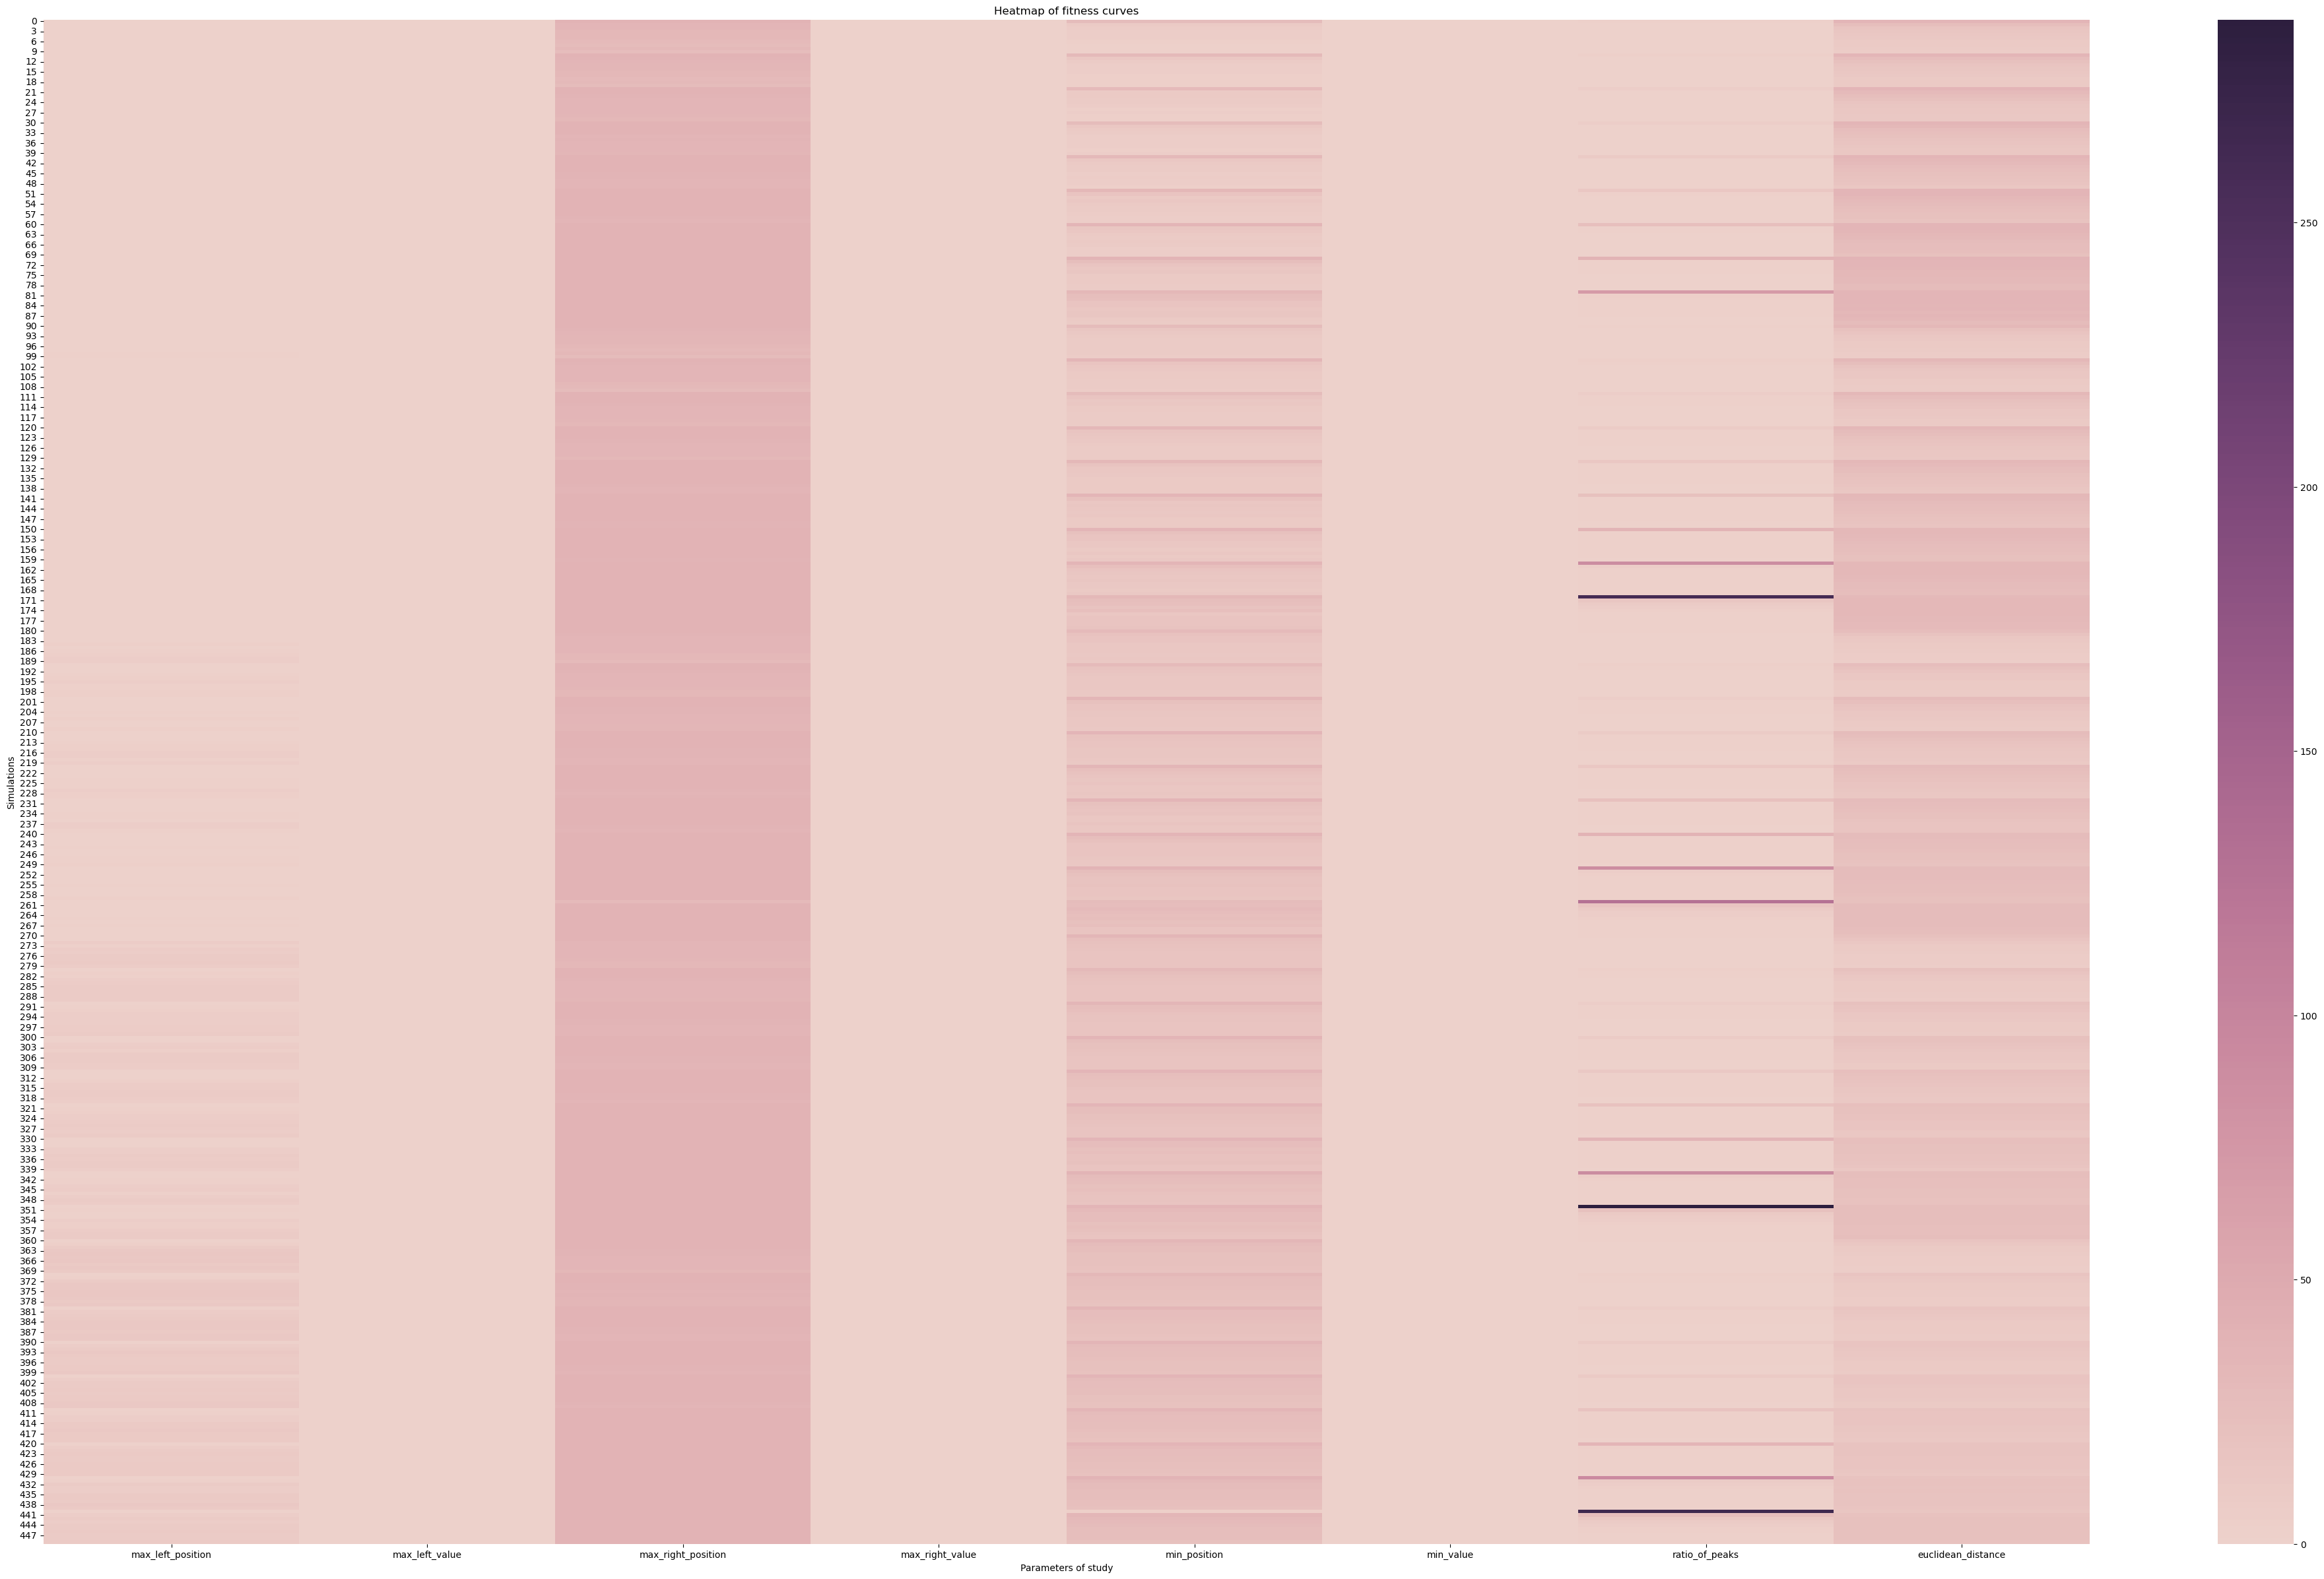

In [12]:
# Create the heatmap
plt.figure(figsize=(50, 30))
cmap=sns.cubehelix_palette(as_cmap=True)
sns.heatmap(sorted_numeric_df, cmap=cmap, cbar=True)
plt.title("Heatmap of fitness curves")
plt.xlabel("Parameters of study")
plt.ylabel("Simulations")
plt.show()

#### **Histogram for each output parameter**

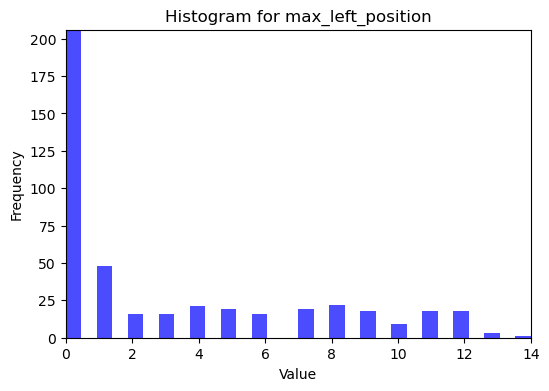

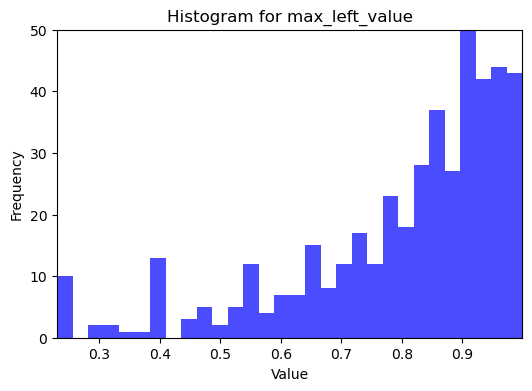

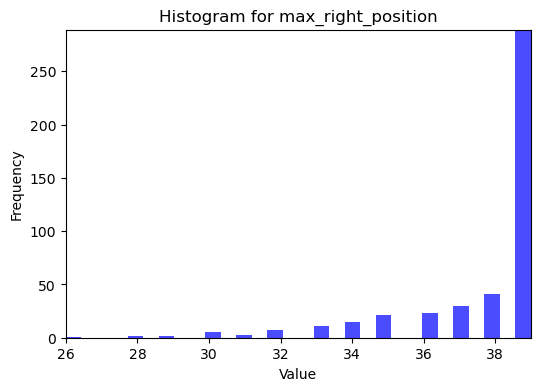

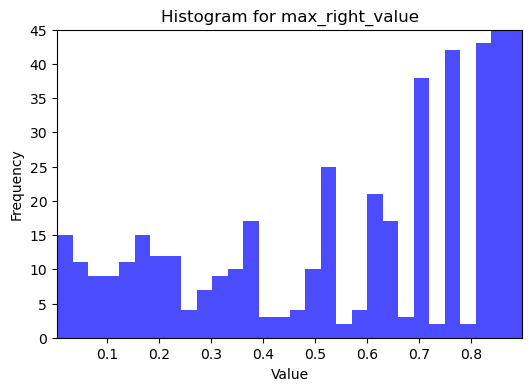

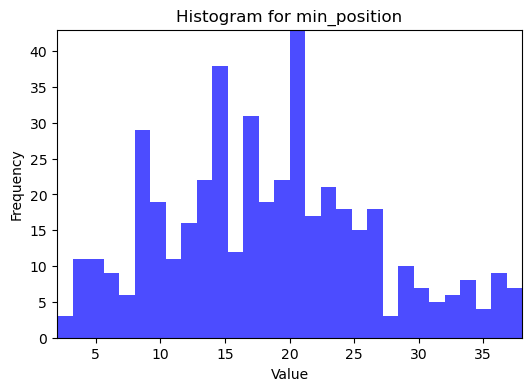

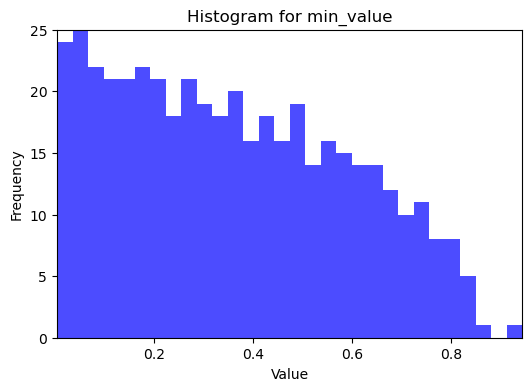

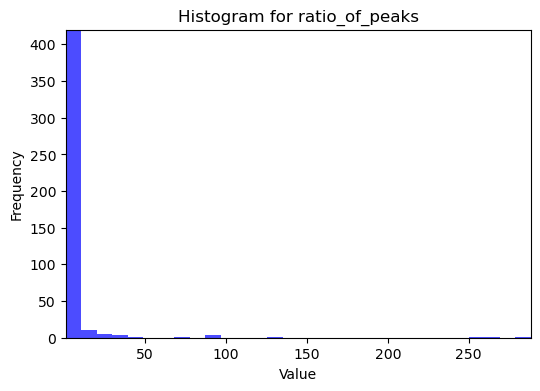

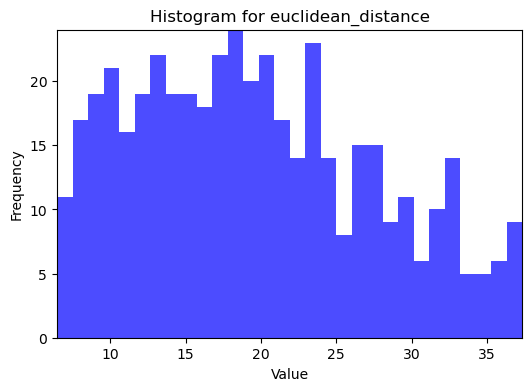

In [13]:
for col in numeric_df.columns:
    # x and y limits
    x_min, x_max = numeric_df[col].min(), numeric_df[col].max()
    counts, _ = np.histogram(numeric_df[col].dropna(), bins=30)
    y_max = counts.max()  

    # Create and show histogram
    plt.figure(figsize=(6, 4))
    plt.hist(numeric_df[col].dropna(), bins=30, alpha=0.7, color="blue")
    plt.title(f"Histogram for {col}")
    plt.xlabel("Value")
    plt.ylabel("Frequency")
    plt.xlim(x_min, x_max)
    plt.ylim(0, y_max)
    plt.show()

#### **Boxplot of the whole data**

In [14]:
##Divide into groups to visualize better

df_1 = pd.DataFrame(columns=["max_left_position","max_right_position","min_position","euclidean_distance"], data=numeric_df)
df_2 = pd.DataFrame(columns=["max_left_value","max_right_value","min_value"], data=numeric_df)
df_3 = pd.DataFrame(columns=["ratio_of_peaks"], data=numeric_df)

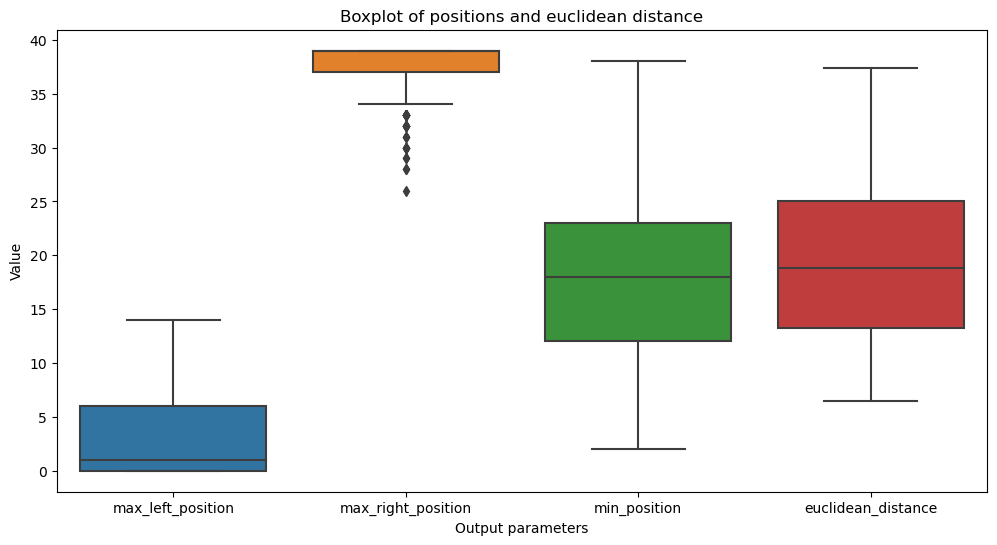

In [15]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_1)
plt.title("Boxplot of positions and euclidean distance")
plt.xlabel("Output parameters")
plt.ylabel("Value")
plt.show()

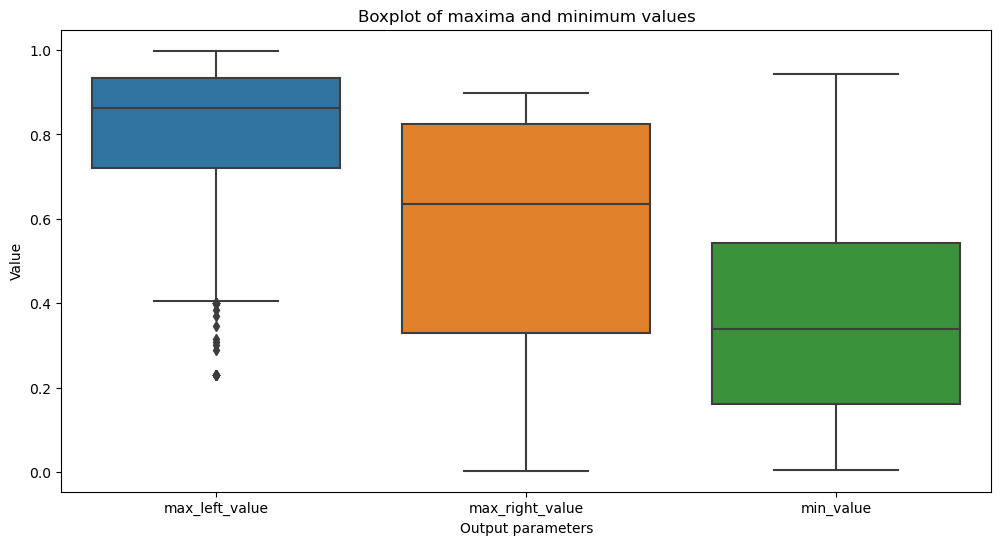

In [16]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_2)
plt.title("Boxplot of maxima and minimum values")
plt.xlabel("Output parameters")
plt.ylabel("Value")
plt.show()

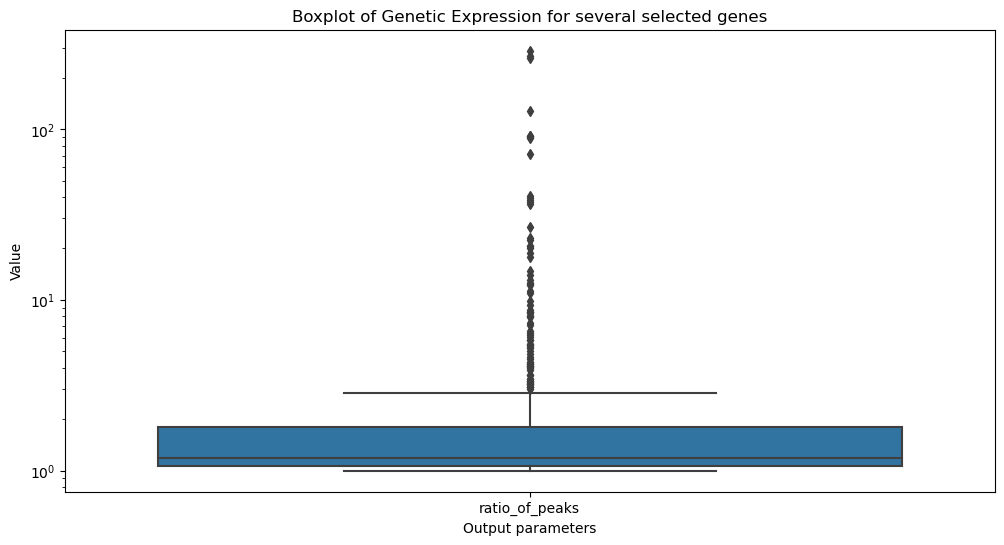

In [17]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_3)
plt.yscale("log")
plt.title("Boxplot of Genetic Expression for several selected genes")
plt.xlabel("Output parameters")
plt.ylabel("Value")
plt.show()

### **Data processing**


#### **Missing data**



In [18]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing values in each column: \n", missing_values)

Missing values in each column: 
 parameters            0
max_left_position     0
max_left_value        0
max_right_position    0
max_right_value       0
min_position          0
min_value             0
ratio_of_peaks        0
euclidean_distance    0
dtype: int64


#### **Standarization**



In [19]:
from sklearn import preprocessing
min_max_scaler = preprocessing.MinMaxScaler()
data_MinMaxScal = pd.DataFrame(min_max_scaler.fit_transform(sorted_numeric_df), columns=sorted_numeric_df.columns)

## Heatmaps after sorting by the input parameters

In [20]:
import pandas as pd

archivo = "/Users/jimenamartinreina/Documents/UNI/MASTER/PRACTICAS_TFM/MODELO/NSP40/ANALYSIS/fitness_data.csv"
df = pd.read_csv(archivo, dtype=str, header=0)  # Cargar todo como string para evitar problemas

# Verifica que la primera columna existe
if df.shape[1] > 0:
    df[['a', 'g', 'pEndemic']] = df.iloc[:, 0].str.split('_', expand=True).astype(float)
    df = df.sort_values(by=['pEndemic', 'g', 'a'])
    df.to_csv("ANALYSIS/sorted_fitness_data_pEndemic.csv", sep="\t", index=False, header=True)
    print("Archivo ordenado guardado como 'sorted_fitness_data_pEndemic.csv'")
else:
    print("Error: No se encontraron columnas en el archivo.")

Archivo ordenado guardado como 'sorted_fitness_data_pEndemic.csv'


**Sorting by 'pEndemic' first, 'g' second and 'a' third**

In [21]:
open("/Users/jimenamartinreina/Documents/UNI/MASTER/PRACTICAS_TFM/MODELO/NSP40/ANALYSIS/sorted_fitness_data_pEndemic.csv", "r")
sorted_df_pEndemic = pd.read_csv('/Users/jimenamartinreina/Documents/UNI/MASTER/PRACTICAS_TFM/MODELO/NSP40/ANALYSIS/sorted_fitness_data_pEndemic.csv',engine='python', sep='\t')
sorted_numeric_df_pEndemic = sorted_df_pEndemic.select_dtypes(include=[np.number])
data_Sc = pd.DataFrame(min_max_scaler.fit_transform(sorted_numeric_df_pEndemic), columns=sorted_numeric_df_pEndemic.columns)

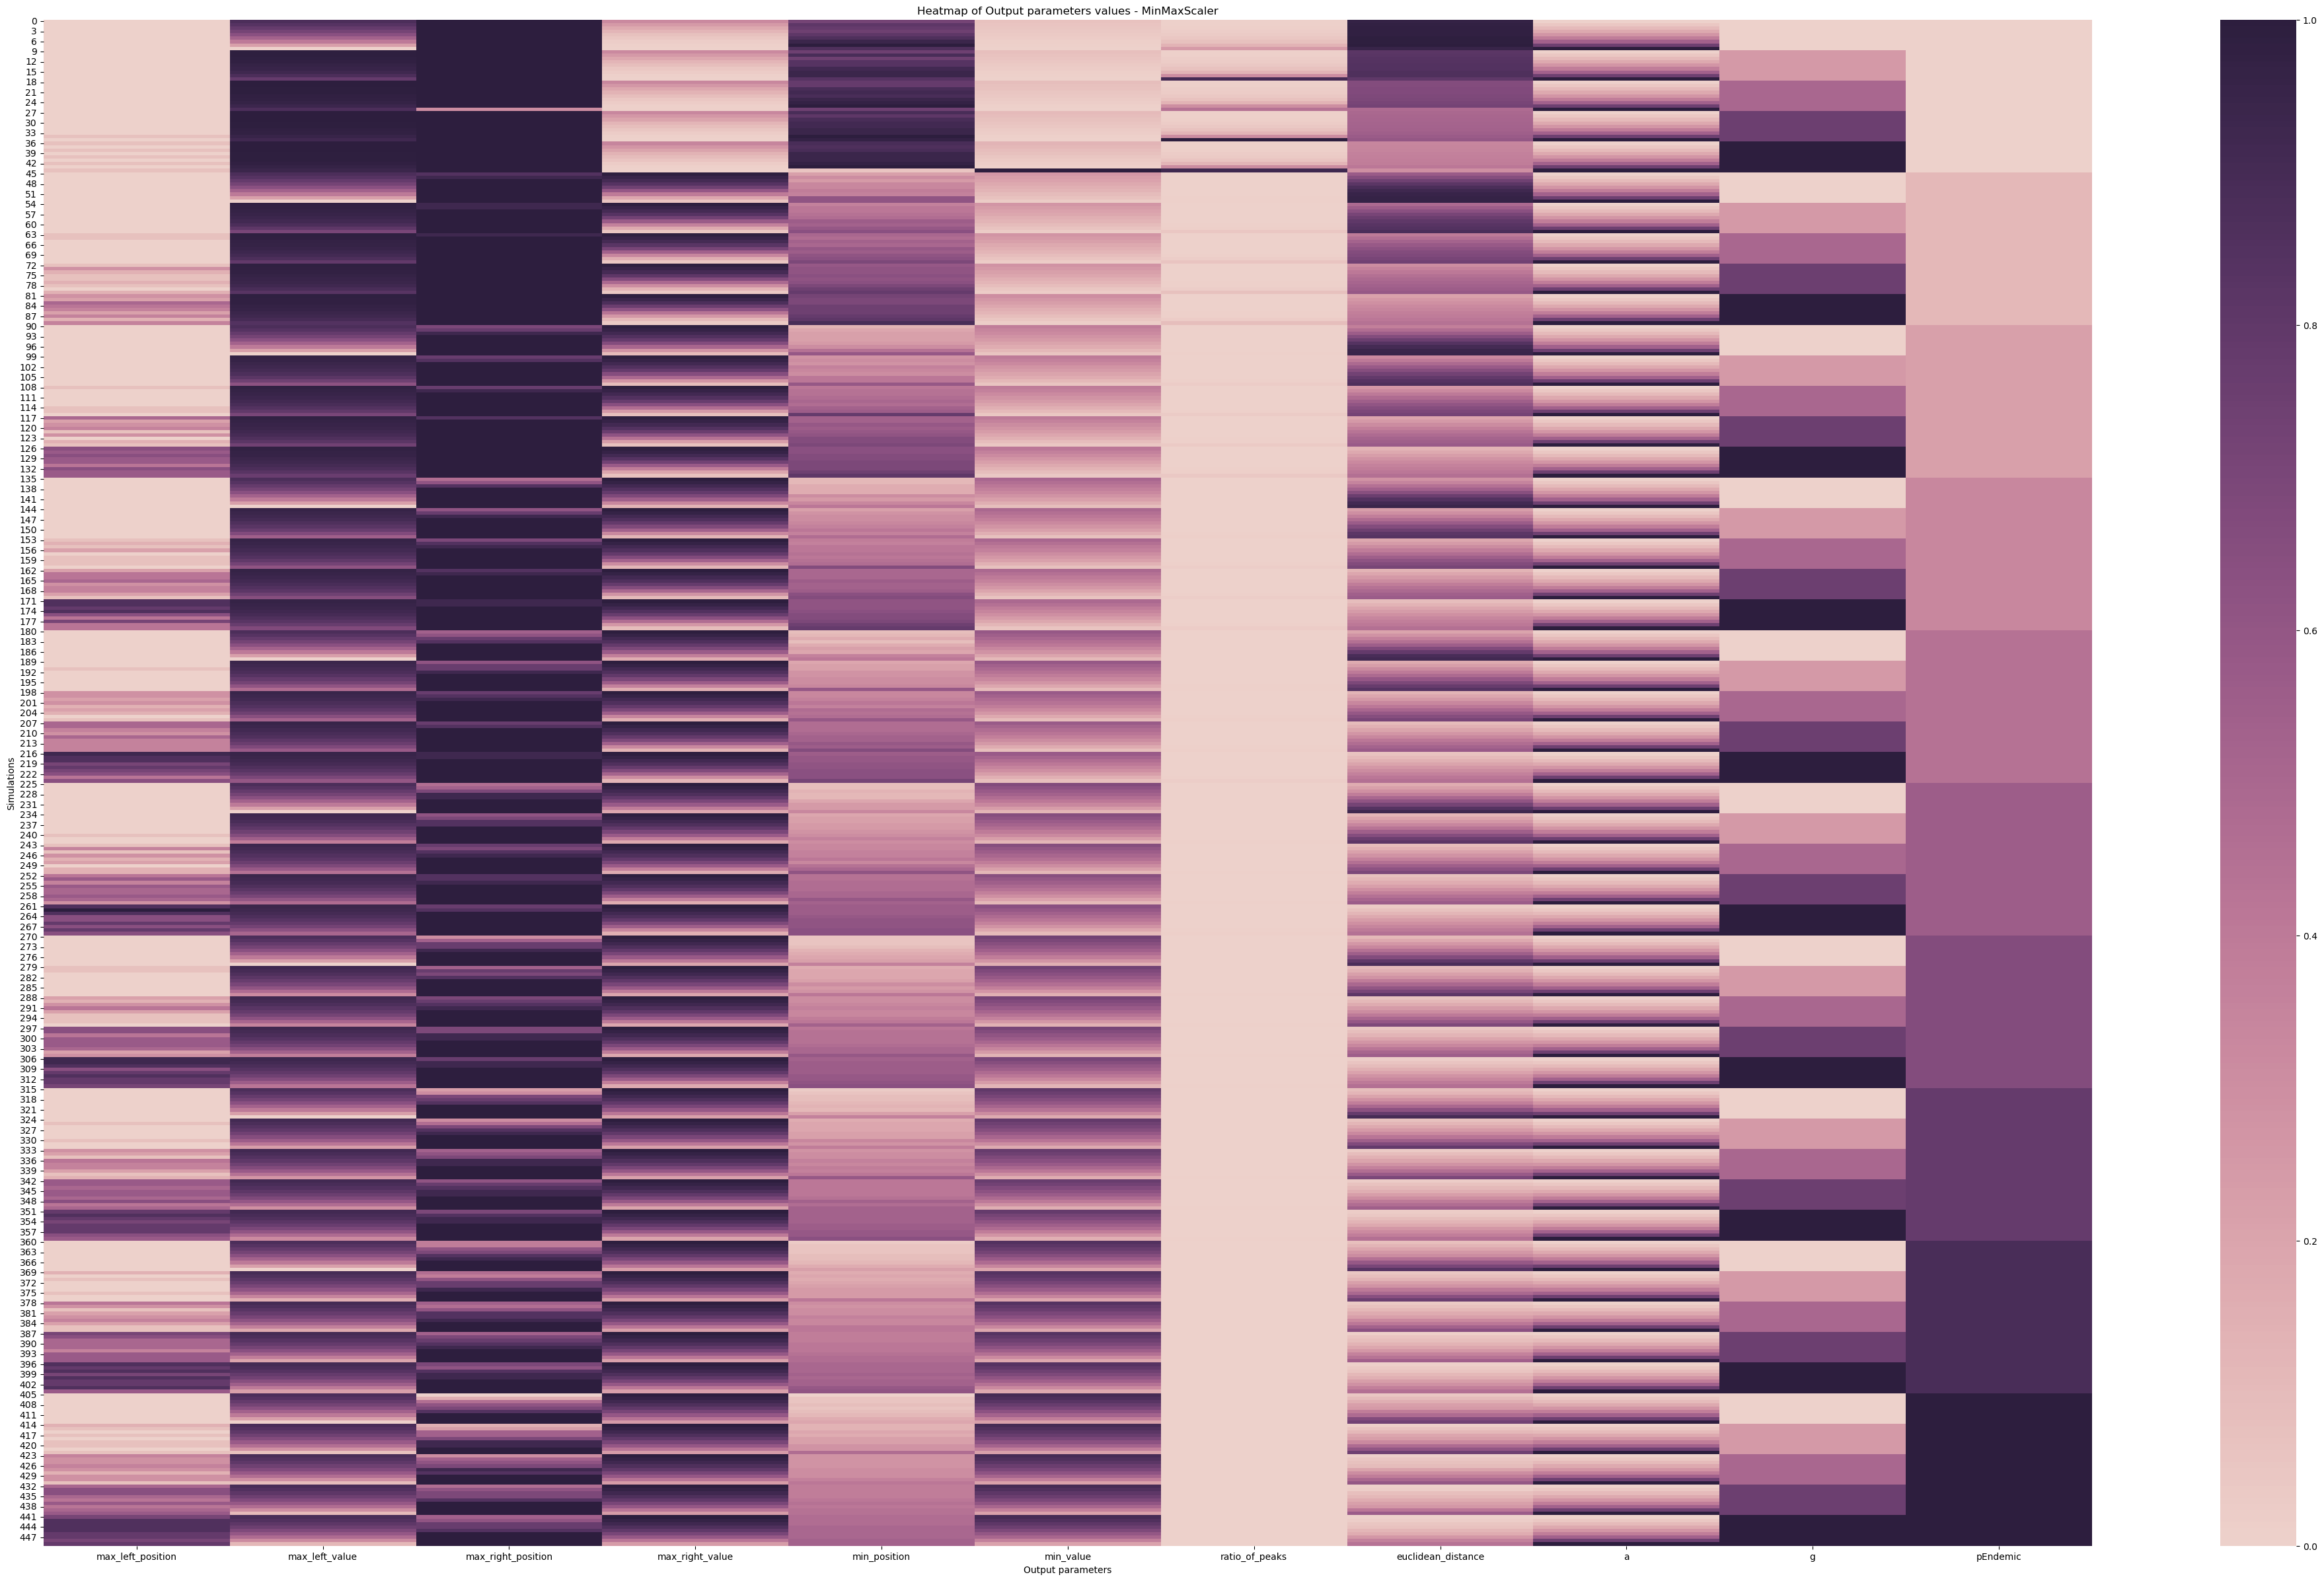

In [22]:
plt.figure(figsize=(50, 30))
cmap=sns.cubehelix_palette(as_cmap=True)
sns.heatmap(data_Sc, cmap=cmap, cbar=True)
plt.title("Heatmap of Output parameters values - MinMaxScaler")
plt.xlabel("Output parameters")
plt.ylabel("Simulations")
plt.show()

**Sorting by 'g' first, 'a' second and 'pEndemic' third**

In [23]:
sorted_df_g = sorted_numeric_df_pEndemic
sorted_df_g['g'] = sorted_df_g['g'].astype(float)  
sorted_df_g = sorted_df_g.sort_values(by=['g','a','pEndemic'])
data_Sc = pd.DataFrame(min_max_scaler.fit_transform(sorted_df_g), columns=sorted_df_g.columns)

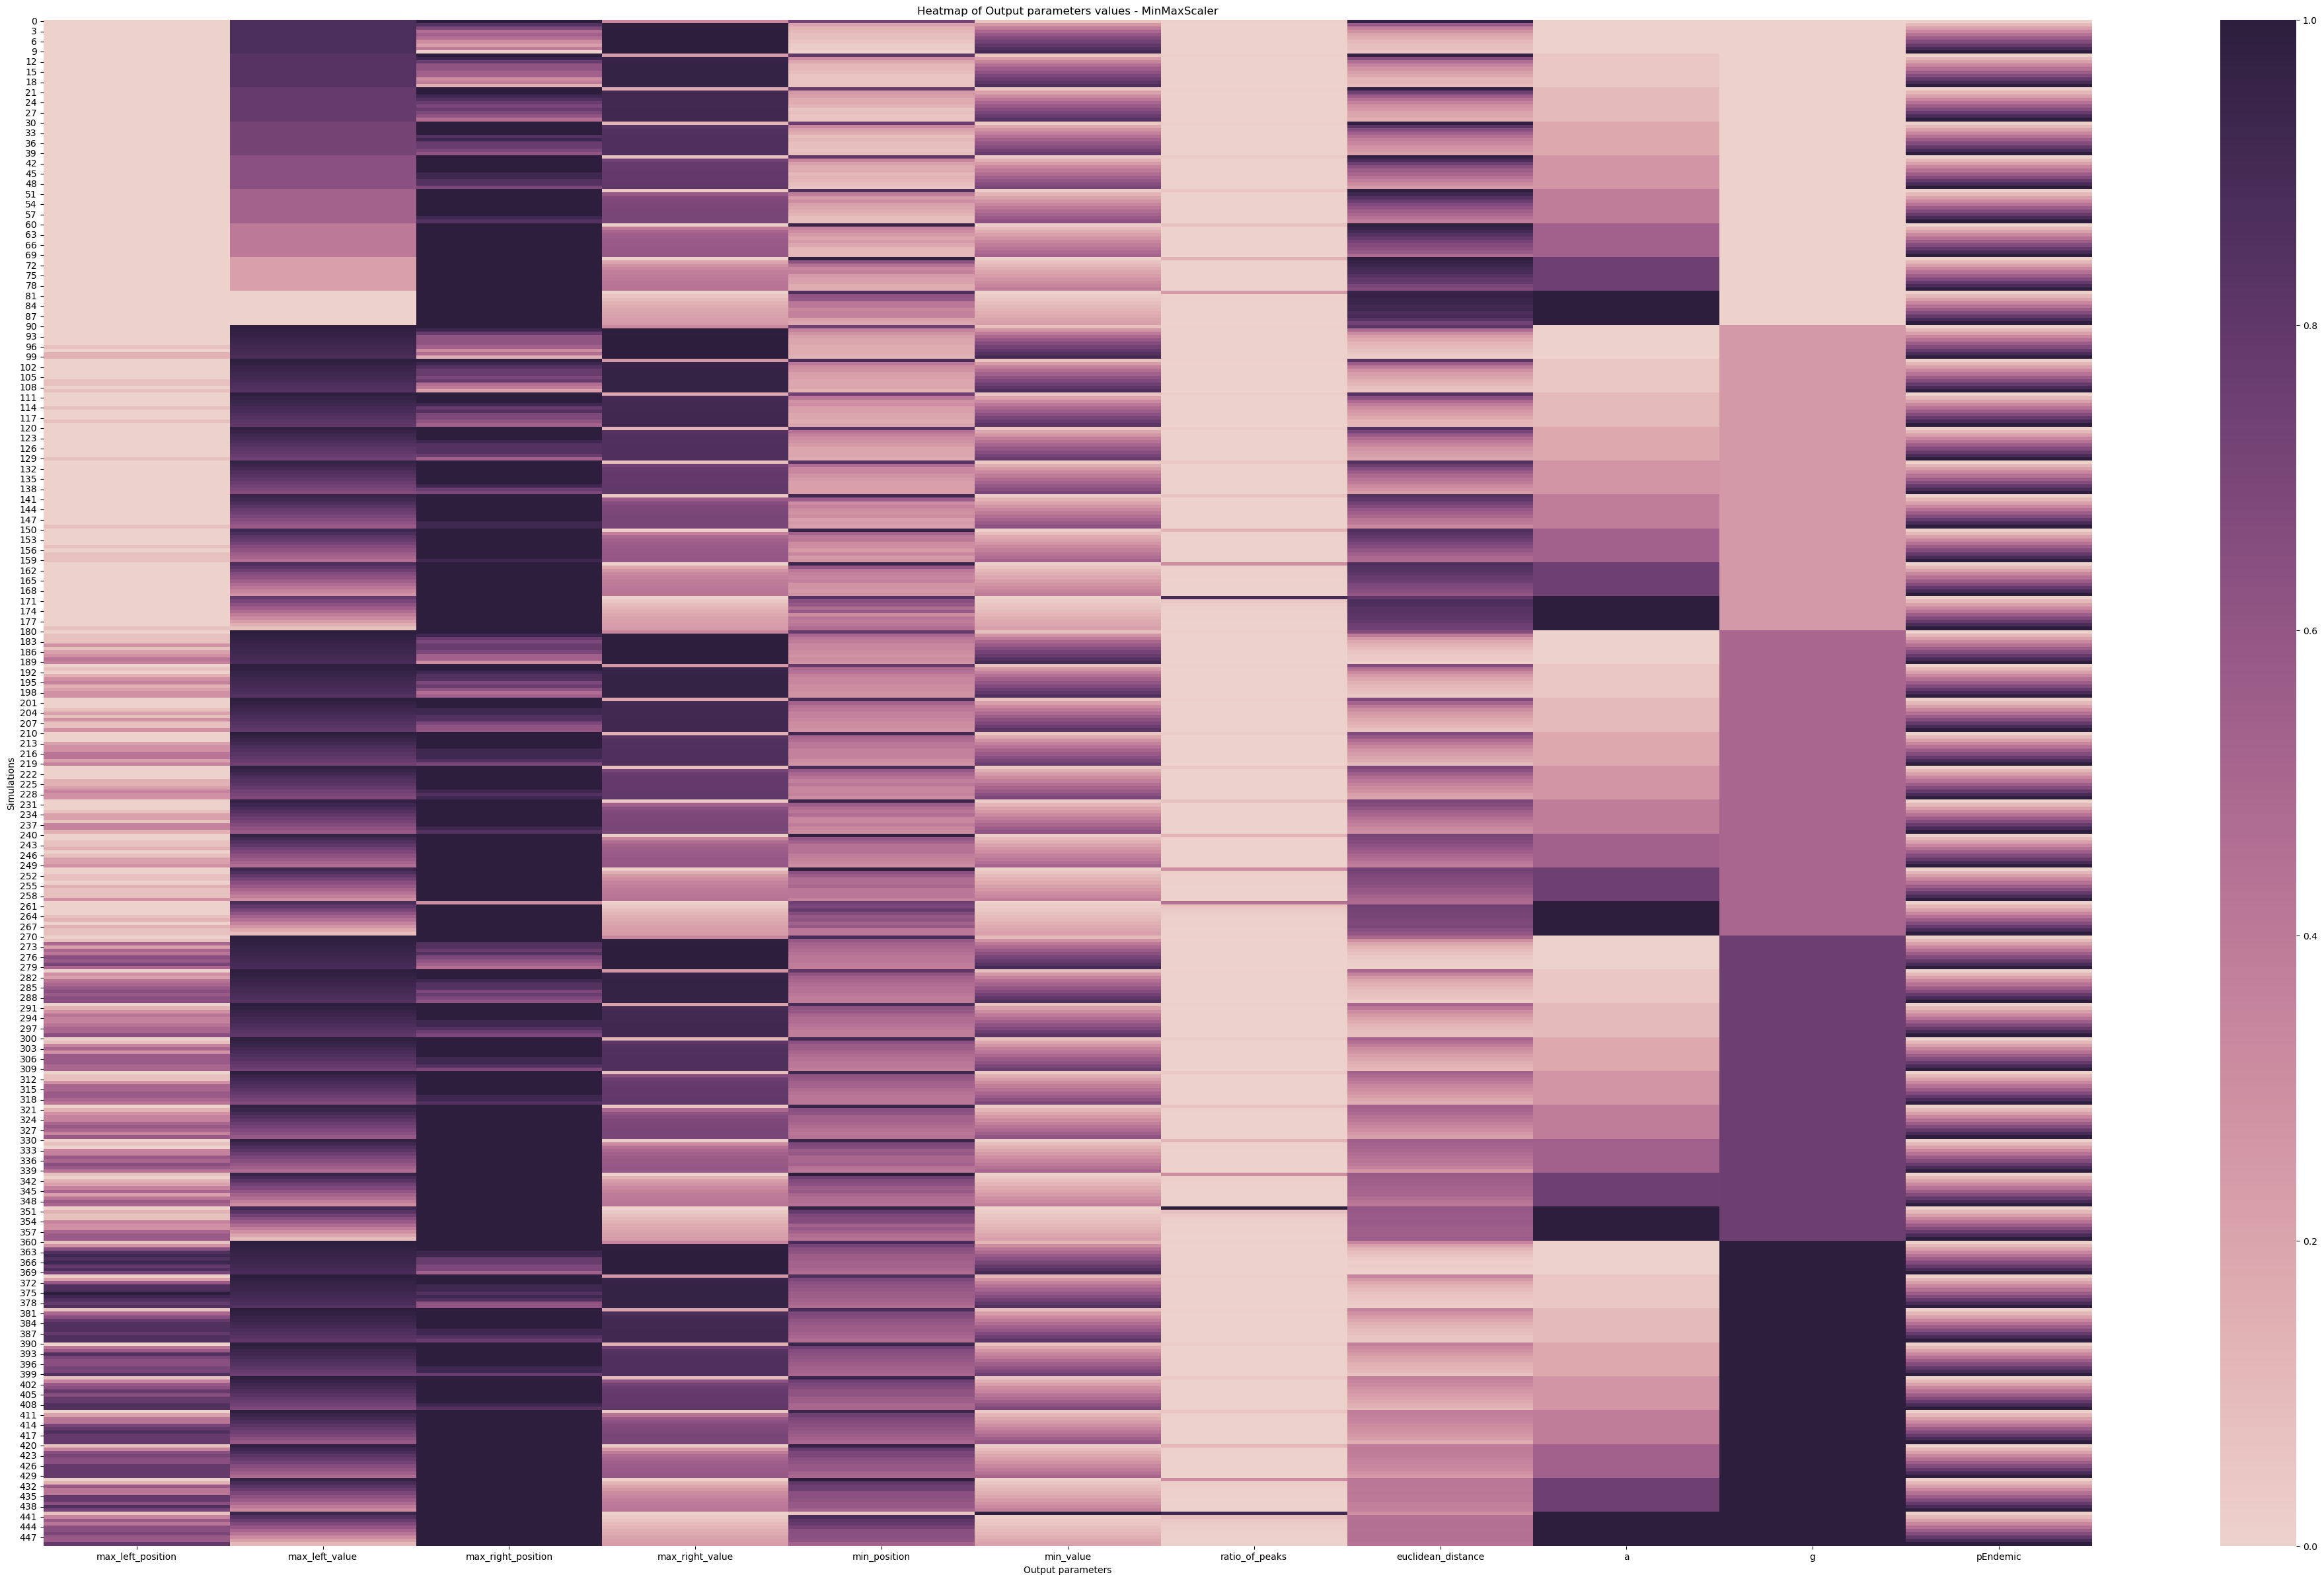

In [24]:
plt.figure(figsize=(50, 30))
cmap=sns.cubehelix_palette(as_cmap=True)
sns.heatmap(data_Sc, cmap=cmap, cbar=True)
plt.title("Heatmap of Output parameters values - MinMaxScaler")
plt.xlabel("Output parameters")
plt.ylabel("Simulations")
plt.show()

**Sorting by 'a' first, 'pEndemic' second and 'g' third**

In [25]:
sorted_df_a = sorted_numeric_df_pEndemic
sorted_df_a['a'] = sorted_df_g['a'].astype(float)  
sorted_df_a = sorted_df_a.sort_values(by=['a','pEndemic','g'])
data_Sc = pd.DataFrame(min_max_scaler.fit_transform(sorted_df_a), columns=sorted_df_a.columns)

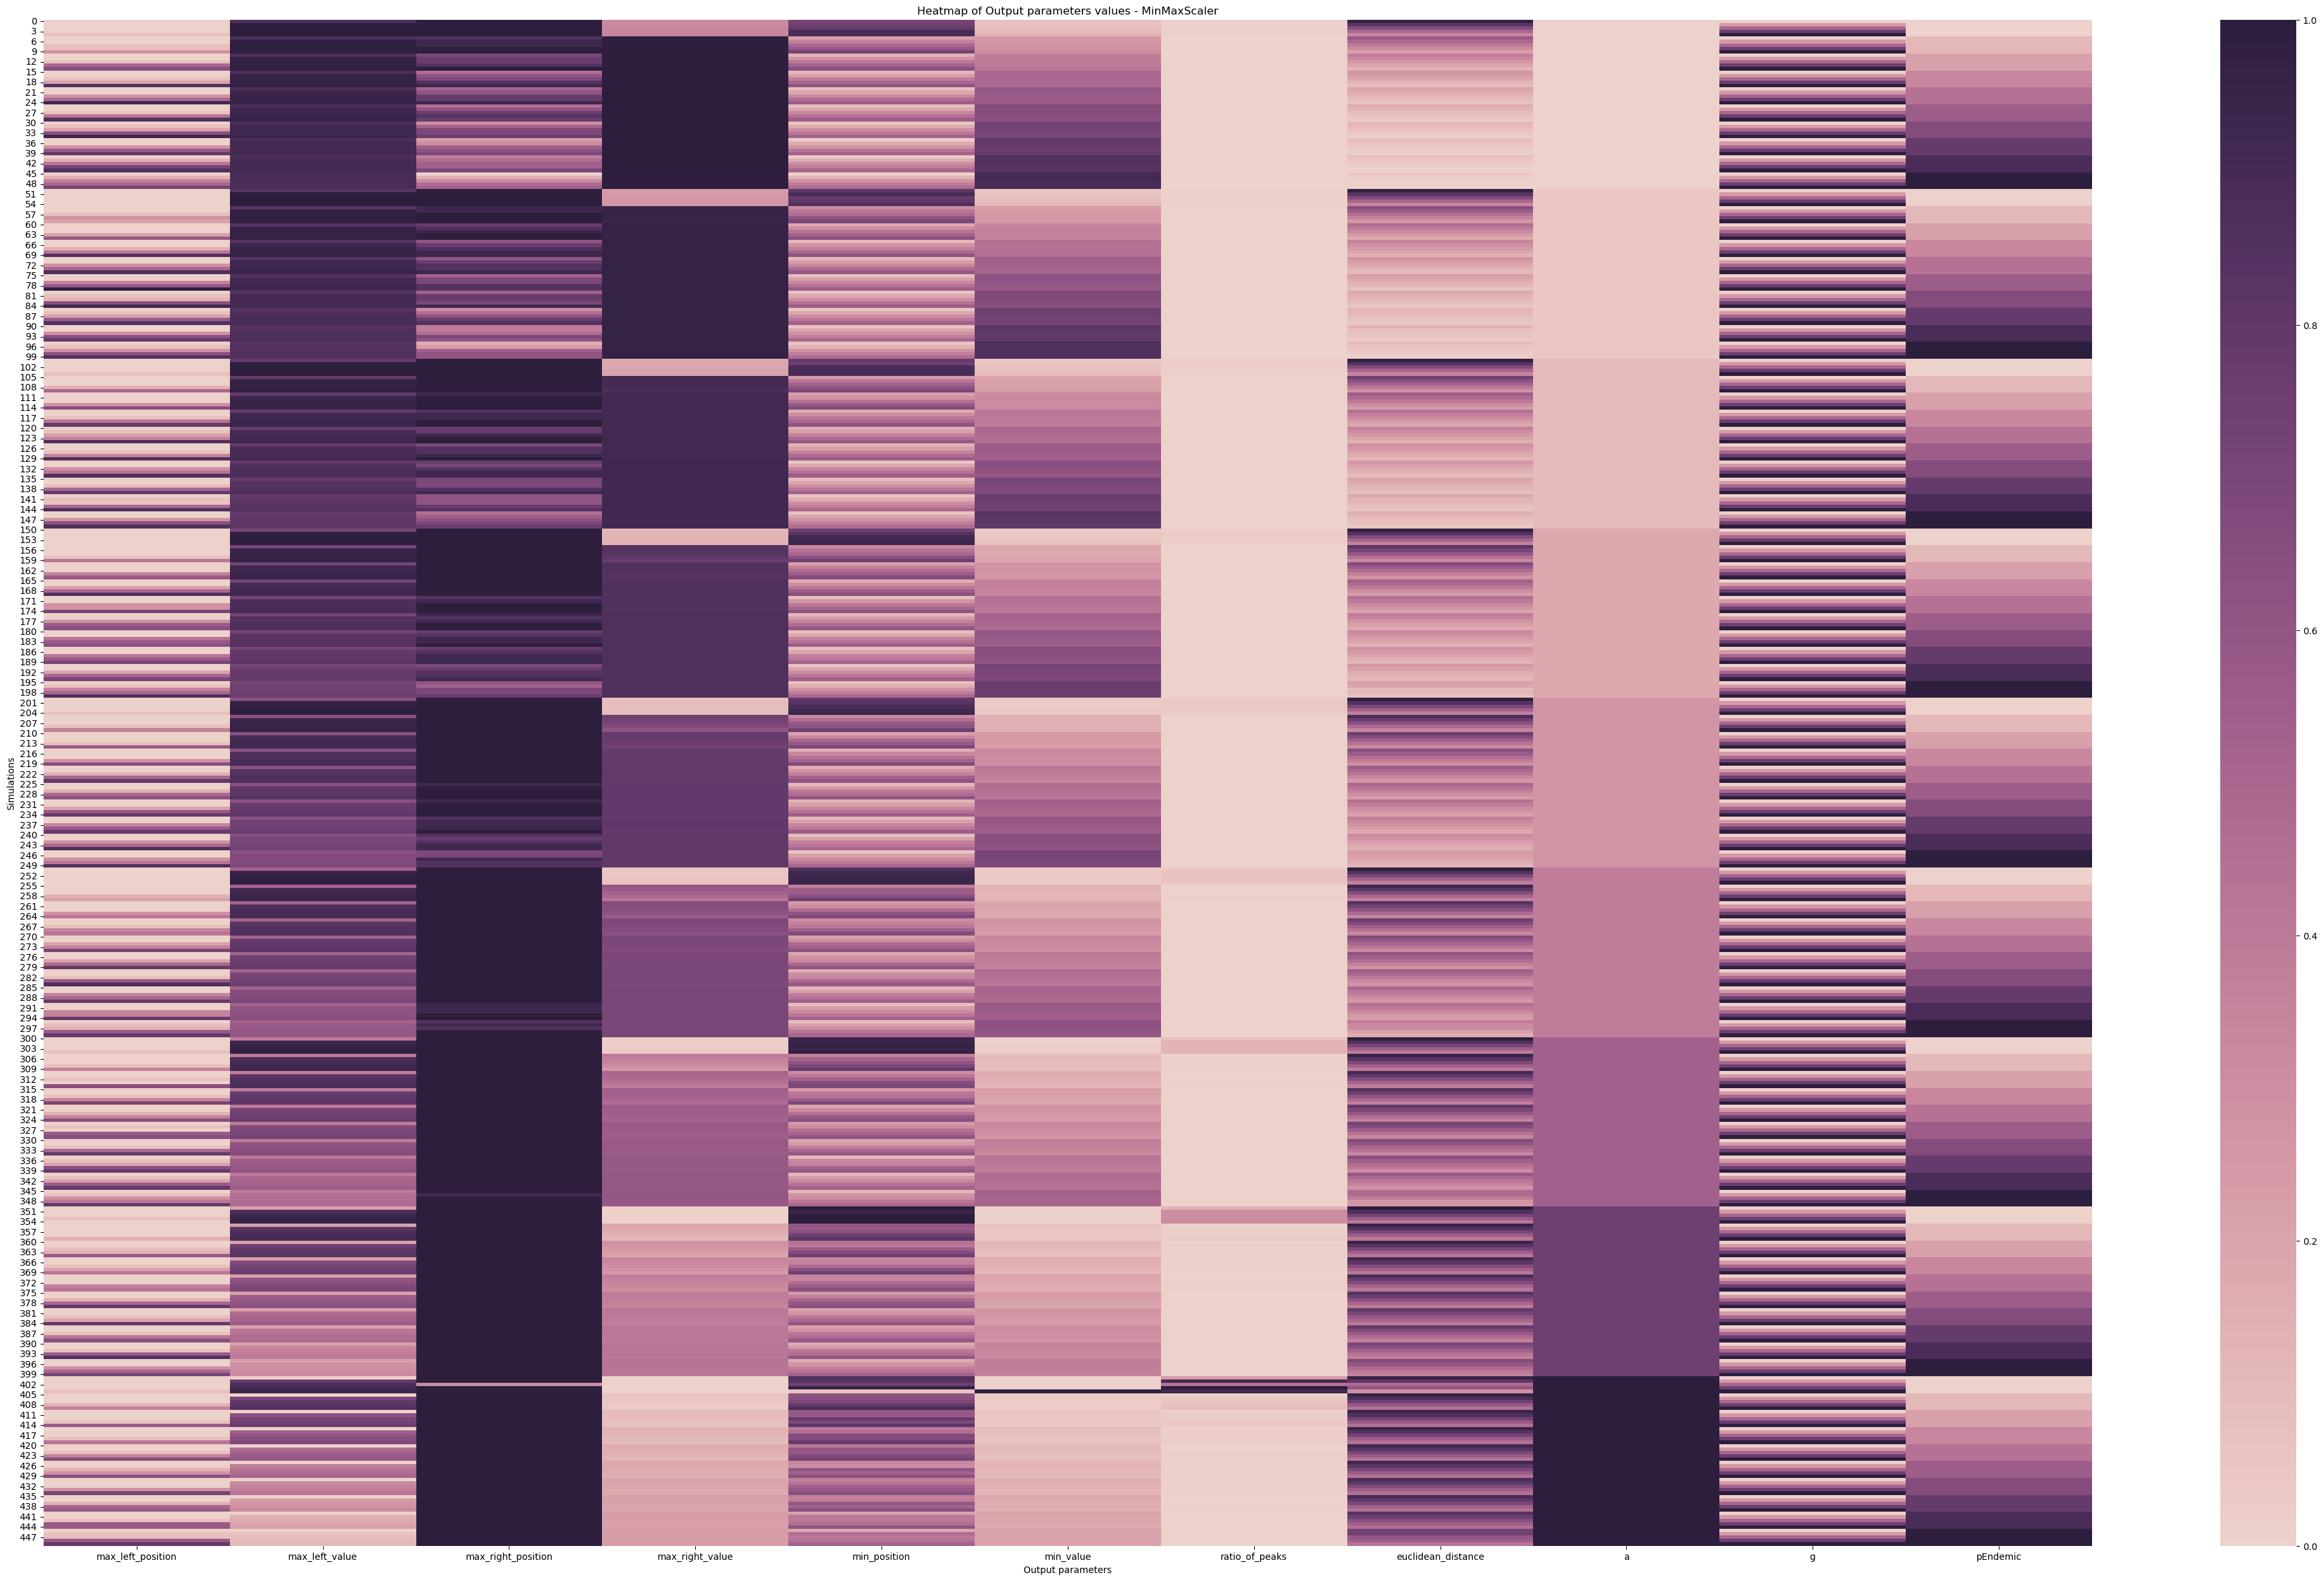

In [26]:
plt.figure(figsize=(50, 30))
cmap=sns.cubehelix_palette(as_cmap=True)
sns.heatmap(data_Sc, cmap=cmap, cbar=True)
plt.title("Heatmap of Output parameters values - MinMaxScaler")
plt.xlabel("Output parameters")
plt.ylabel("Simulations")
plt.show()

###### In these heatmaps generated after applying the `MinMaxScaler`:

- The values have been scaled between 0 and 1. 
- Values equal to 1 means they were originally the maximum **of the column**. For instance, in max_right_position column, values of 1 (dark purple, almost black) represent the last spacer of the CRISPR array.
- Values equal to 0 means they were originally the minimum **of the column**. For instance, in max_left_position column, values of 0 (light pink, the lighter color) represent the first spacer of the CRIPSR array.

## Heatmaps after sorting for the output parameters

In [59]:
archivo = "/Users/jimenamartinreina/Documents/UNI/MASTER/PRACTICAS_TFM/MODELO/NSP40/ANALYSIS/fitness_data.csv"
df = pd.read_csv(archivo, dtype=str, header=0)  # Cargar todo como string para evitar problemas

if 'max_left_position' in df.columns:
    df[['a', 'g', 'pEndemic']] = df.iloc[:, 0].str.split('_', expand=True).astype(float)
    df['max_left_position'] = df['max_left_position'].astype(float)  # Convertir a número
    df = df.sort_values(by=['max_left_position'])
    df.to_csv("ANALYSIS/sorted_fitness_data_maxleftpos.csv", sep="\t", index=False, header=True)
    print("File saved as 'sorted_fitness_data_maxleftpos.csv'")
else:
    print("Error: La columna 'max_left_position' no se encontró en el archivo.")

File saved as 'sorted_fitness_data_maxleftpos.csv'


In [60]:
open("/Users/jimenamartinreina/Documents/UNI/MASTER/PRACTICAS_TFM/MODELO/NSP40/ANALYSIS/sorted_fitness_data_maxleftpos.csv", "r")

<_io.TextIOWrapper name='/Users/jimenamartinreina/Documents/UNI/MASTER/PRACTICAS_TFM/MODELO/NSP40/ANALYSIS/sorted_fitness_data_maxleftpos.csv' mode='r' encoding='UTF-8'>

In [61]:
sorted_df_maxleftpos = pd.read_csv('/Users/jimenamartinreina/Documents/UNI/MASTER/PRACTICAS_TFM/MODELO/NSP40/ANALYSIS/sorted_fitness_data_maxleftpos.csv',engine='python', sep='\t')

In [62]:
sorted_df_maxleftpos = sorted_df_maxleftpos[['max_left_position','a','g','pEndemic']]

In [63]:
data_Sc = pd.DataFrame(min_max_scaler.fit_transform(sorted_df_maxleftpos), columns=sorted_df_maxleftpos.columns)

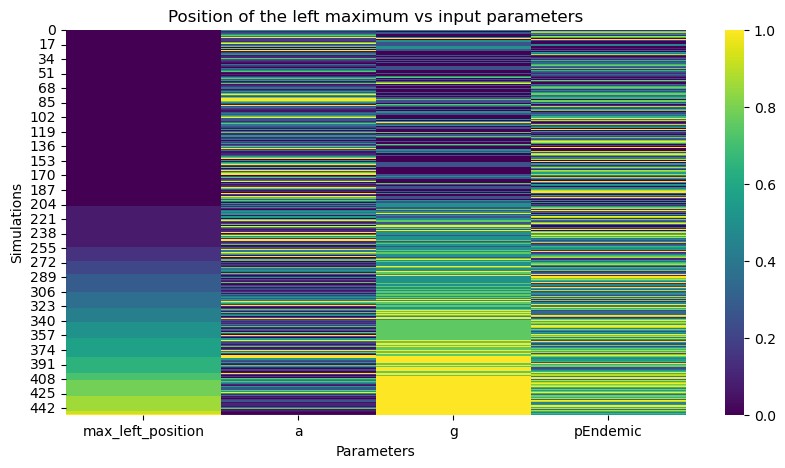

In [64]:
plt.figure(figsize=(10, 5))
sns.heatmap(data_Sc, cmap="viridis", cbar=True)
plt.title("Position of the left maximum vs input parameters")
plt.xlabel("Parameters")
plt.ylabel("Simulations")
plt.show()

In [65]:
file = '/Users/jimenamartinreina/Documents/UNI/MASTER/PRACTICAS_TFM/MODELO/NSP40/ANALYSIS/sorted_fitness_data_maxleftpos.csv'

In [66]:
sorted_df_maxleftval = pd.read_csv(file, dtype=str, header=0, sep='\t')
sorted_df_maxleftval['max_left_value'] = sorted_df_maxleftval['max_left_value'].astype(float)  
sorted_df_maxleftval = sorted_df_maxleftval.sort_values(by=['max_left_value'])
sorted_df_maxleftval = sorted_df_maxleftval[['max_left_value','a','g','pEndemic']]
data_Sc = pd.DataFrame(min_max_scaler.fit_transform(sorted_df_maxleftval), columns=sorted_df_maxleftval.columns)

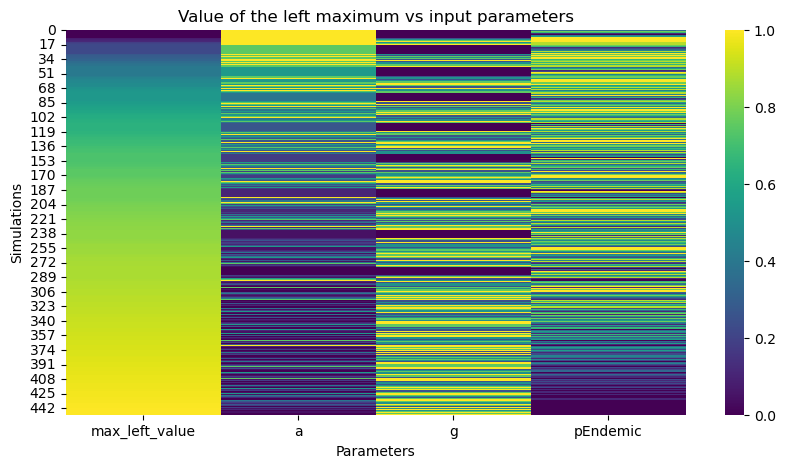

In [67]:
plt.figure(figsize=(10, 5))
sns.heatmap(data_Sc, cmap="viridis", cbar=True)
plt.title("Value of the left maximum vs input parameters")
plt.xlabel("Parameters")
plt.ylabel("Simulations")
plt.show()

In [79]:
sorted_df_maxrightpos = pd.read_csv(file, dtype=str, header=0, sep='\t')
sorted_df_maxrightpos['max_right_position'] = sorted_df_maxrightpos['max_right_position'].astype(float)  
sorted_df_maxrightpos = sorted_df_maxrightpos.sort_values(by=['max_right_position'])
sorted_df_maxrightpos = sorted_df_maxrightpos[['max_right_position','a','g','pEndemic']]
data_Sc = pd.DataFrame(min_max_scaler.fit_transform(sorted_df_maxrightpos), columns=sorted_df_maxrightpos.columns)

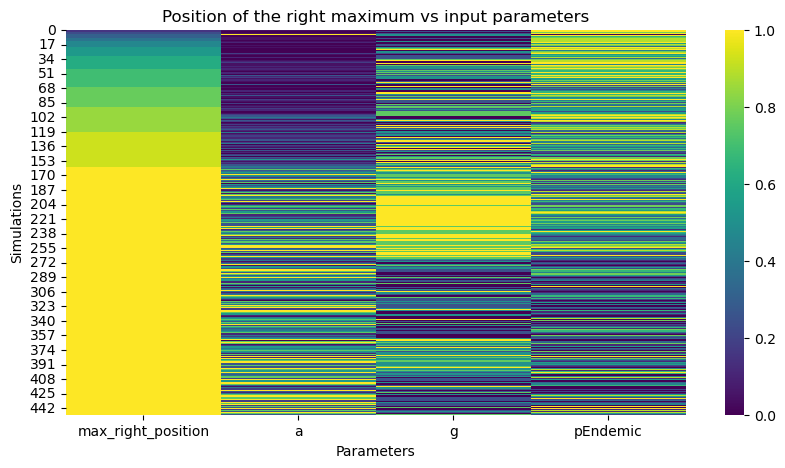

In [80]:
plt.figure(figsize=(10, 5))
sns.heatmap(data_Sc, cmap="viridis", cbar=True)
plt.title("Position of the right maximum vs input parameters")
plt.xlabel("Parameters")
plt.ylabel("Simulations")
plt.show()

In [81]:
sorted_df_maxrightval = pd.read_csv(file, dtype=str, header=0, sep='\t')
sorted_df_maxrightval['max_right_value'] = sorted_df_maxrightval['max_right_value'].astype(float)  
sorted_df_maxrightval = sorted_df_maxrightval.sort_values(by=['max_right_value'])
sorted_df_maxrightval = sorted_df_maxrightval[['max_right_value','a','g','pEndemic']]
data_Sc = pd.DataFrame(min_max_scaler.fit_transform(sorted_df_maxrightval), columns=sorted_df_maxrightval.columns)

In [82]:
# To see why pEndemic is sorted in the heatmap
df = pd.read_csv(archivo, dtype=str, header=0)
if 'max_right_value' in df.columns:
    df[['a', 'g', 'pEndemic']] = df.iloc[:, 0].str.split('_', expand=True).astype(float)
    df['max_right_value'] = df['max_right_value'].astype(float)  # Convertir a número
    df = df.sort_values(by=['max_right_value'])
    df.to_csv("ANALYSIS/sorted_fitness_data_maxrightval.csv", sep="\t", index=False, header=True)
    print("File saved as 'sorted_fitness_data_maxrightval.csv'")
else:
    print("Error: La columna 'max_right_value' no se encontró en el archivo.")

File saved as 'sorted_fitness_data_maxrightval.csv'


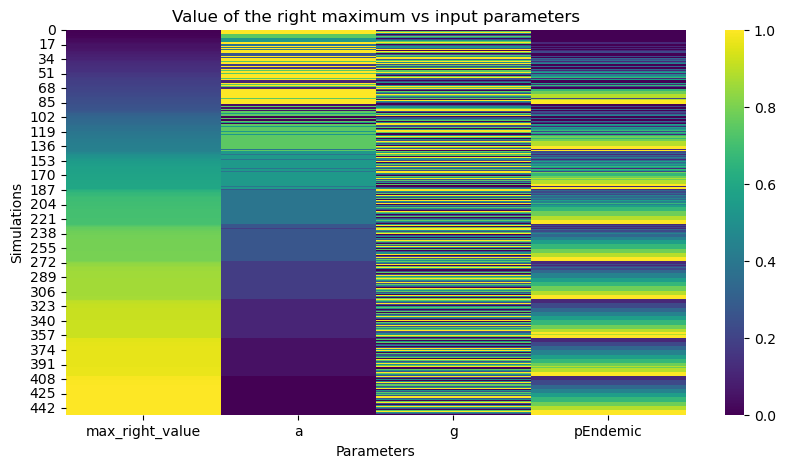

In [83]:
plt.figure(figsize=(10, 5))
sns.heatmap(data_Sc, cmap="viridis", cbar=True)
plt.title("Value of the right maximum vs input parameters")
plt.xlabel("Parameters")
plt.ylabel("Simulations")
plt.show()

In [41]:
sorted_df_minpos = pd.read_csv(file, dtype=str, header=0, sep='\t')
sorted_df_minpos['min_position'] = sorted_df_minpos['min_position'].astype(float)  
sorted_df_minpos = sorted_df_minpos.sort_values(by=['min_position'])
sorted_df_minpos = sorted_df_minpos[['min_position','a','g','pEndemic']]
data_Sc = pd.DataFrame(min_max_scaler.fit_transform(sorted_df_minpos), columns=sorted_df_minpos.columns)

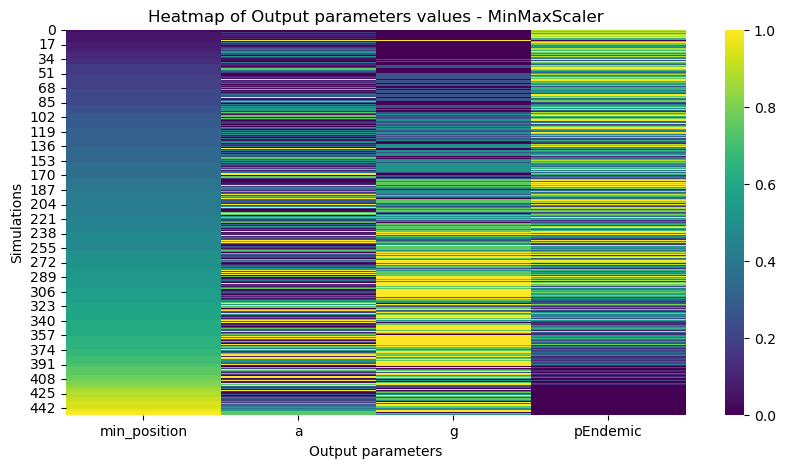

In [42]:
plt.figure(figsize=(10, 5))
sns.heatmap(data_Sc, cmap="viridis", cbar=True)
plt.title("Heatmap of Output parameters values - MinMaxScaler")
plt.xlabel("Output parameters")
plt.ylabel("Simulations")
plt.show()

In [43]:
sorted_df_minval = pd.read_csv(file, dtype=str, header=0, sep='\t')
sorted_df_minval['min_value'] = sorted_df_minval['min_value'].astype(float)  
sorted_df_minval = sorted_df_minval.sort_values(by=['min_value'])
sorted_df_minval = sorted_df_minval[['min_value','a','g','pEndemic']]
data_Sc = pd.DataFrame(min_max_scaler.fit_transform(sorted_df_minval), columns=sorted_df_minval.columns)

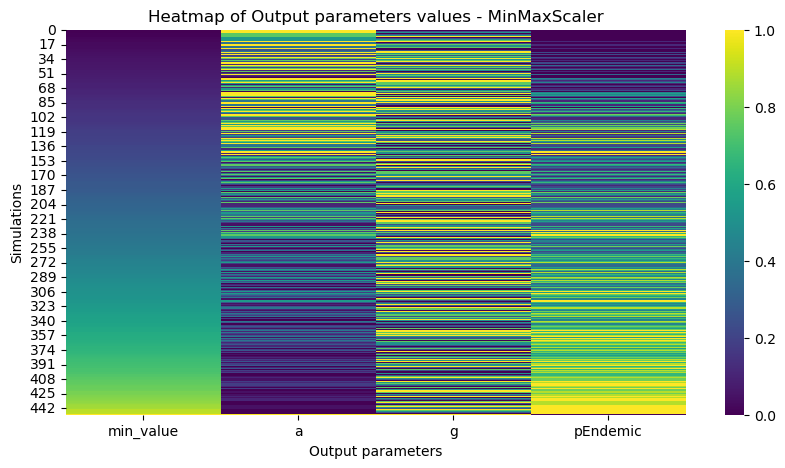

In [44]:
plt.figure(figsize=(10, 5))
sns.heatmap(data_Sc, cmap="viridis", cbar=True)
plt.title("Heatmap of Output parameters values - MinMaxScaler")
plt.xlabel("Output parameters")
plt.ylabel("Simulations")
plt.show()

In [45]:
sorted_df_rat = pd.read_csv(file, dtype=str, header=0, sep='\t')
sorted_df_rat['ratio_of_peaks'] = sorted_df_rat['ratio_of_peaks'].astype(float)  
sorted_df_rat = sorted_df_rat.sort_values(by=['ratio_of_peaks'])
sorted_df_rat = sorted_df_rat[['ratio_of_peaks','a','g','pEndemic']]
data_Sc = pd.DataFrame(min_max_scaler.fit_transform(sorted_df_rat), columns=sorted_df_rat.columns)

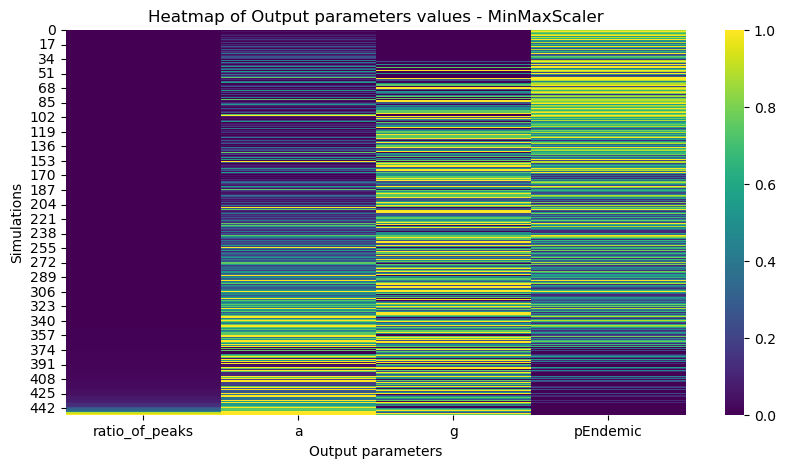

In [46]:
plt.figure(figsize=(10, 5))
sns.heatmap(data_Sc, cmap="viridis", cbar=True)
plt.title("Heatmap of Output parameters values - MinMaxScaler")
plt.xlabel("Output parameters")
plt.ylabel("Simulations")
plt.show()

In [84]:
sorted_df_dis = pd.read_csv(file, dtype=str, header=0, sep='\t')
sorted_df_dis['euclidean_distance'] = sorted_df_dis['euclidean_distance'].astype(float)  
sorted_df_dis = sorted_df_dis.sort_values(by=['euclidean_distance'])
sorted_df_dis = sorted_df_dis[['euclidean_distance','a','g','pEndemic']]
data_Sc = pd.DataFrame(min_max_scaler.fit_transform(sorted_df_dis), columns=sorted_df_dis.columns)

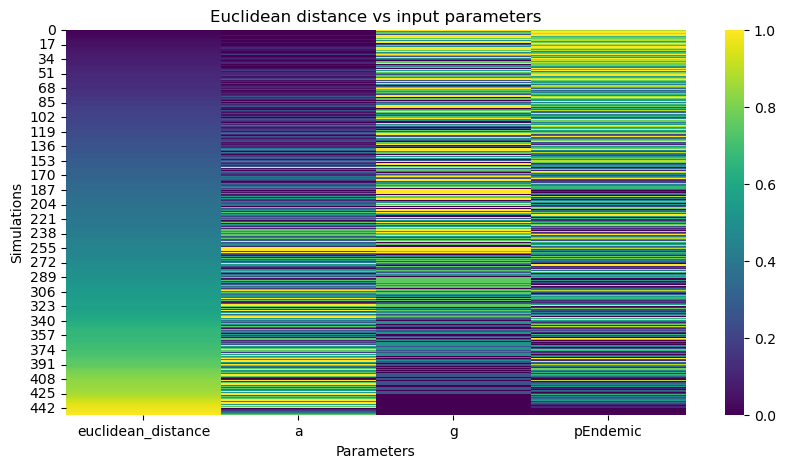

In [85]:
plt.figure(figsize=(10, 5))
sns.heatmap(data_Sc, cmap="viridis", cbar=True)
plt.title("Euclidean distance vs input parameters")
plt.xlabel("Parameters")
plt.ylabel("Simulations")
plt.show()

**References**

https://seaborn.pydata.org/generated/seaborn.heatmap.html